In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
df = pd.read_csv('car data.csv')

print("--- Dataset Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

--- First 5 Rows ---
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2

In [ ]:
current_year = 2026
df['Age'] = current_year - df['Year']

# Drop 'Car_Name' (too many unique categories for a small dataset) and original 'Year'
df = df.drop(['Car_Name', 'Year'], axis=1)

# Separate features (X) and target variable (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [ ]:
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']
numerical_cols = ['Present_Price', 'Driven_kms', 'Owner', 'Age']

# Define the preprocessing pipeline (One-Hot Encoding for categorical data)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. MODEL BUILDING USING A PIPELINE
# Combining preprocessing and model training keeps the code clean and prevents data leakage
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [ ]:
model_pipeline.fit(X_train, y_train)
print("\nModel training completed successfully!")

# 5. MODEL EVALUATION
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²) Score: {r2:.4f} (An R² close to 1 implies an excellent fit)")



Model training completed successfully!

--- Model Performance Evaluation ---
Mean Absolute Error (MAE): 0.64
Root Mean Squared Error (RMSE): 0.97
R-squared (R²) Score: 0.9595 (An R² close to 1 implies an excellent fit)


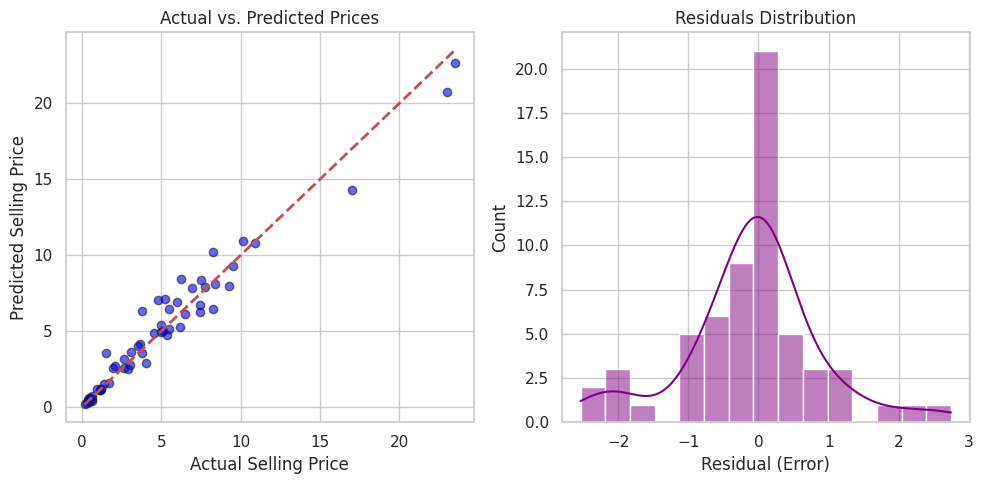

In [ ]:
plt.figure(figsize=(10, 5))

# Plot Actual vs Predicted Prices
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs. Predicted Prices')

# Plot Residuals (Errors) Distribution
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel('Residual (Error)')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()